In [ ]:
# Import library yang dibutuhkan
import tensorflow as tf
#tf.random.set_seed(3)
from tensorflow.keras import layers, Model
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
#  Load dataset
df = pd.read_csv("DATASET SKRIPSI.csv")

x = df.drop(["Sleep_Quality", "Stress_Level", "ID"], axis=1)
sleep = df["Sleep_Quality"]
stress = df["Stress_Level"]

df

,ID,Age,Gender,Coffee_Intake,Caffeine_mg,Sleep_Hours,BMI,Stress_Level,Physical_Activity_Hours,Smoking,Alcohol_Consumption,Sleep_Quality
0,1,40,Male,3.5,328.1,7.5,24.9,Low,14.5,0,0,Good
1,2,33,Male,1.0,94.1,6.2,20.0,Low,11.0,0,0,Good
2,3,42,Male,5.3,503.7,5.9,22.7,Medium,11.2,0,0,Fair
3,4,53,Male,2.6,249.2,7.3,24.7,Low,6.6,0,0,Good
4,5,32,Female,3.1,298.0,5.3,24.1,Medium,8.5,0,1,Fair
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,50,Female,2.1,199.8,6.0,30.5,Medium,10.1,0,1,Fair
9996,9997,18,Female,3.4,319.2,5.8,19.1,Medium,11.6,0,0,Fair
9997,9998,26,Male,1.6,153.4,7.1,25.1,Low,13.7,1,1,Good
9998,9999,40,Female,3.4,327.1,7.0,19.3,Low,0.1,0,0,Good


In [ ]:
x["Gender"] = x["Gender"].map({"Male": 0,"Female": 1,"Other": 2})
stress = stress.map({"Low": 0,"Medium": 1,"High": 2})
sleep = sleep.map({"Poor": 0,"Fair": 1,"Good": 2,"Excellent": 3})

stratify_combined = sleep.astype(str) + "_" + stress.astype(str)

#  Split data menjadi train dan test
X_train, X_test, sleep_train, sleep_test, stress_train, stress_test = train_test_split(
    x, sleep, stress, test_size=0.2, stratify=stratify_combined, random_state=42)

#  Normalisasi fitur / Preprocesor
num_col = ['Age', 'Coffee_Intake', 'Caffeine_mg', 'Sleep_Hours', 'BMI', 'Physical_Activity_Hours']
cat_col = ['Gender', 'Smoking', 'Alcohol_Consumption']

preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), num_col),
    ('cat', 'passthrough', cat_col)
])

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

In [ ]:
all_cols = num_col + cat_col
X_train_df = pd.DataFrame(X_train_prep, columns=all_cols)

X_train_df

,Age,Coffee_Intake,Caffeine_mg,Sleep_Hours,BMI,Physical_Activity_Hours,Gender,Smoking,Alcohol_Consumption
0,0.048387,0.243902,0.239780,0.328571,0.198276,0.160000,1.0,1.0,0.0
1,0.419355,0.439024,0.442138,0.671429,0.422414,0.206667,1.0,1.0,1.0
2,0.258065,0.365854,0.363450,0.457143,0.607759,0.560000,0.0,0.0,1.0
3,0.838710,0.170732,0.173010,0.814286,0.232759,0.600000,1.0,1.0,0.0
4,0.000000,0.304878,0.302448,0.685714,0.073276,0.086667,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...
7995,0.112903,0.048780,0.052672,0.585714,0.456897,0.060000,0.0,0.0,0.0
7996,0.322581,0.390244,0.386262,0.542857,0.318966,0.620000,0.0,0.0,1.0
7997,0.322581,0.170732,0.173779,0.657143,0.568966,0.446667,0.0,0.0,0.0
7998,0.338710,0.390244,0.390235,0.442857,0.306034,0.426667,1.0,1.0,1.0


In [ ]:
# Input layer
input_layer = layers.Input(shape=(9,), name="input_features")

# Shared hidden layers
hidden = layers.Dense(100, activation="relu")(input_layer)
dropout = layers.Dropout(0.2)(hidden)

# Output 1: kualitas tidur
sleep_output = layers.Dense(4,activation="softmax",name="prediksi_tidur")(dropout)

# Output 2: tingkat stres
stress_output = layers.Dense(3,activation="softmax", name="prediksi_stres")(dropout)

# Membuat model
model = Model(
    inputs = input_layer,
    outputs = [sleep_output, stress_output]
)

In [ ]:
model.compile(
    optimizer = 'adam',
    loss = {
        "prediksi_tidur": "sparse_categorical_crossentropy",
        "prediksi_stres": "sparse_categorical_crossentropy"
    },
    metrics = {
        "prediksi_tidur": "accuracy",
        "prediksi_stres": "accuracy"
    }
)

In [ ]:
history = model.fit(
    x=X_train_prep,
    y={
        "prediksi_tidur": sleep_train,
        "prediksi_stres": stress_train
    },
    epochs=1000,
    batch_size=1000,
    validation_split=0.2,
    verbose=1
)

Epoch 1/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - loss: 2.4020 - prediksi_stres_accuracy: 0.3577 - prediksi_stres_loss: 1.0522 - prediksi_tidur_accuracy: 0.2645 - prediksi_tidur_loss: 1.3440 - val_loss: 2.3067 - val_prediksi_stres_accuracy: 0.4606 - val_prediksi_stres_loss: 0.9960 - val_prediksi_tidur_accuracy: 0.2644 - val_prediksi_tidur_loss: 1.3114
Epoch 2/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 2.2688 - prediksi_stres_accuracy: 0.5347 - prediksi_stres_loss: 0.9652 - prediksi_tidur_accuracy: 0.3861 - prediksi_tidur_loss: 1.2947 - val_loss: 2.1834 - val_prediksi_stres_accuracy: 0.7013 - val_prediksi_stres_loss: 0.9177 - val_prediksi_tidur_accuracy: 0.5606 - val_prediksi_tidur_loss: 1.2656
Epoch 3/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 2.1569 - prediksi_stres_accuracy: 0.6772 - prediksi_stres_loss: 0.9020 - prediksi_tidur_accuracy: 0.5180 - prediksi_tidur_loss: 1.2510 - val_loss: 2.0795 - val_prediksi_stres_accuracy: 0.7050 - val_prediksi_stres_loss: 0.8570 -

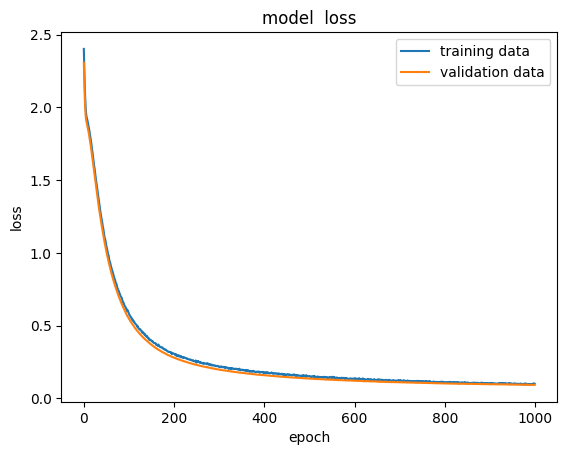

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('model  loss')
plt.ylabel('loss')
plt.xlabel('epoch')

plt.legend(['training data', 'validation data'])
plt.savefig('loss accurary.png', dpi=300)

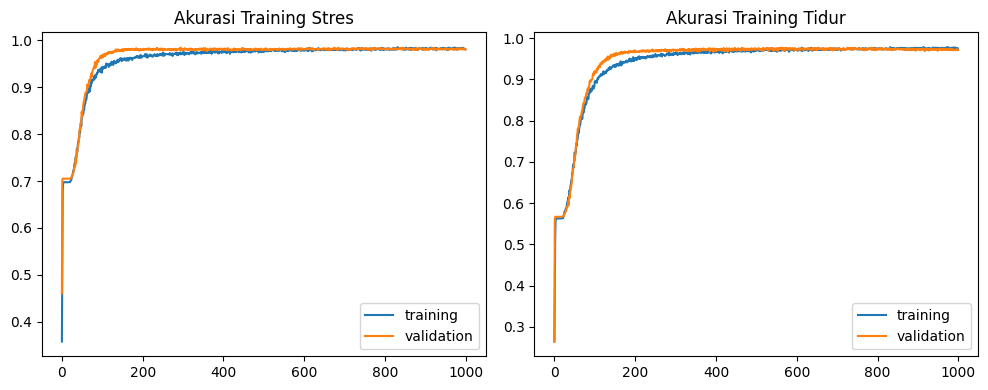

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# Loss
axs[0].plot(history.history['prediksi_stres_accuracy'], label='training')
axs[0].plot(history.history['val_prediksi_stres_accuracy'], label='validation')
axs[0].set_title('Akurasi Training Stres')
axs[0].legend()

# Accuracy
axs[1].plot(history.history['prediksi_tidur_accuracy'], label='training')
axs[1].plot(history.history['val_prediksi_tidur_accuracy'], label='validation')
axs[1].set_title('Akurasi Training Tidur')
axs[1].legend()

plt.tight_layout()
plt.savefig('training accurary.png', dpi=300)
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


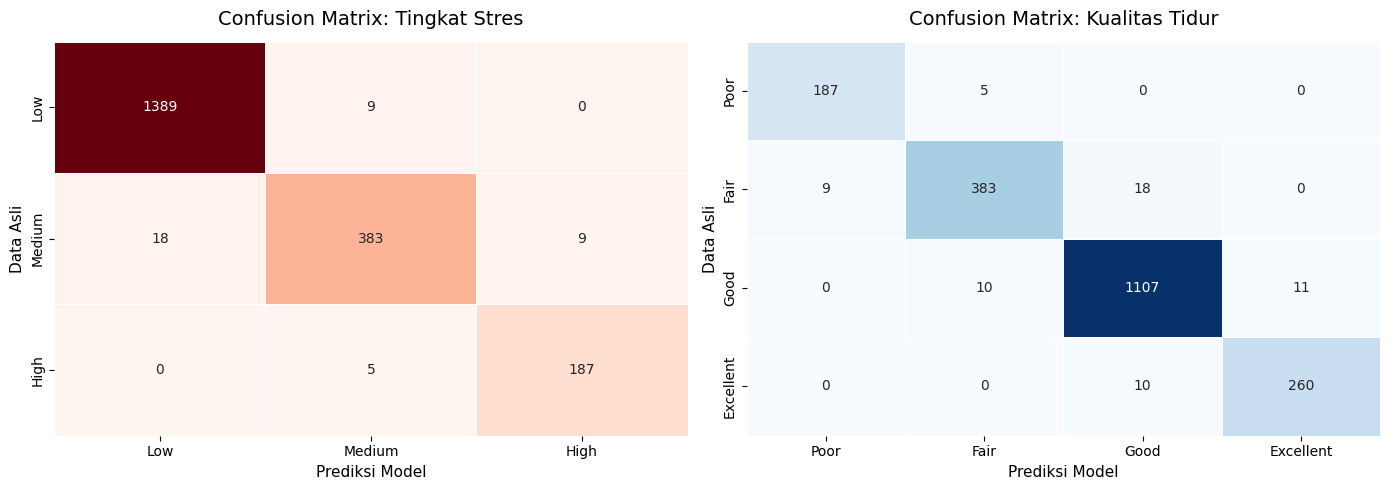

In [ ]:
prediction = model.predict(X_test_prep)
sleep_pred = np.argmax(prediction[0], axis=1)
stress_pred = np.argmax(prediction[1], axis=1)

cm_stres = confusion_matrix(stress_test, stress_pred)
cm_tidur = confusion_matrix(sleep_test, sleep_pred)

#  Membuat Visualisasi Heatmap Berdampingan (1 baris, 2 kolom grafik)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Grafik Kiri: Tingkat Stres (3 Kelas: Low, Medium, High) ---
label_stres = ['Low', 'Medium', 'High']
sns.heatmap(cm_stres, annot=True, fmt='d', cmap='Reds', ax=axes[0], cbar=False,
            xticklabels=label_stres, yticklabels=label_stres, linewidths=0.5)
axes[0].set_title('Confusion Matrix: Tingkat Stres', fontsize=14, pad=12)
axes[0].set_xlabel('Prediksi Model', fontsize=11)
axes[0].set_ylabel('Data Asli', fontsize=11)

# --- Grafik Kanan: Kualitas Tidur (4 Kelas: Poor, Fair, Good, Excellent) ---
label_tidur = ['Poor', 'Fair', 'Good', 'Excellent']
sns.heatmap(cm_tidur, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False,
            xticklabels=label_tidur, yticklabels=label_tidur, linewidths=0.5)
axes[1].set_title('Confusion Matrix: Kualitas Tidur', fontsize=14, pad=12)
axes[1].set_xlabel('Prediksi Model', fontsize=11)
axes[1].set_ylabel('Data Asli', fontsize=11)


plt.tight_layout()

# 5. MENYIMPAN GAMBAR UNTUK SKRIPSI
# Kode ini akan menyimpan gambar dalam kualitas HD (300 DPI) agar tidak pecah saat dicetak
plt.savefig('confusion_matrix_skripsi.png', dpi=300)

# Tampilkan grafik di layar
plt.show()

In [ ]:
# 1. Jalankan evaluasi pada data test
results = model.evaluate(
    x=X_test_prep,
    y={
        "prediksi_tidur": sleep_test,
        "prediksi_stres": stress_test
    }
)

# 'results' will be a list in the order: [total_loss, prediksi_tidur_loss, prediksi_stres_loss, prediksi_stres_accuracy, prediksi_tidur_accuracy]
total_loss = results[0]
sleep_loss = results[1]
stress_loss = results[2]
stress_acc = results[3]
sleep_acc = results[4]

print(f"Total Loss pada data uji: {total_loss:.3f}")
print(f"Loss Prediksi Tidur pada data uji: {sleep_loss:.3f}")
print(f"Loss Prediksi Stres pada data uji: {stress_loss:.3f}")
print(f"Akurasi Prediksi Stres pada data uji: {stress_acc:.3f}")
print(f"Akurasi Prediksi Tidur pada data uji: {sleep_acc:.3f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0894 - prediksi_stres_accuracy: 0.9795 - prediksi_stres_loss: 0.0347 - prediksi_tidur_accuracy: 0.9685 - prediksi_tidur_loss: 0.0560
Total Loss pada data uji: 0.089
Loss Prediksi Tidur pada data uji: 0.056
Loss Prediksi Stres pada data uji: 0.035
Akurasi Prediksi Stres pada data uji: 0.979
Akurasi Prediksi Tidur pada data uji: 0.969


In [ ]:
import joblib

# 1. MENYIMPAN PREPROCESSOR (ColumnTransformer / StandardScaler)
# Pastikan variabel 'preprocessor' Anda sudah melalui proses .fit_transform(X_train)
joblib.dump(preprocessor, 'preprocessor.joblib')
print("✅ Preprocessor (Transformasi Data) berhasil disimpan!")

# 2. MENYIAPKAN & MENYIMPAN MODEL ANN TENSORFLOW
# Format .keras akan menyimpan arsitektur, bobot (weights), dan nama output secara utuh
model.save('model_100.keras')
print("✅ Model ANN TensorFlow berhasil disimpan!")

# SIMPAN history ke CSV agar tidak hilang lagi
hist_df = pd.DataFrame(history.history)
hist_df.to_csv('history_100.csv', index=False)
print("✅ History berhasil disimpan!")

✅ Preprocessor (Transformasi Data) berhasil disimpan!
✅ Model ANN TensorFlow berhasil disimpan!
✅ History berhasil disimpan!
